# Fleet Model Runner

Run the fleet model from the config file and load the saved result tables.

# Konfigurierte Policy-Szenarien und BEV-Zielpfade

Die Namen und Prozentwerte werden direkt aus `fleet_model_config.json` gelesen. Neue Einträge unter `bev_target_scenarios` erscheinen automatisch in den Modellresultaten und Diagrammen.

In [10]:
import importlib.util
from pathlib import Path
import pandas as pd

model_dir = Path(r"C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model")
script_path = model_dir / "fleet_model_with_policies.py"
config_path = model_dir / "fleet_model_config.json"

spec = importlib.util.spec_from_file_location("fleet_model_with_policies", script_path)
fleet_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fleet_model)
model_config = fleet_model.load_config(config_path)

fixed_scenarios = model_config["policies"]["scenarios"]
bev_target_scenarios = model_config["policies"].get("bev_target_scenarios", {})
all_scenarios = fleet_model.policy_scenario_names(model_config)

scenario_overview = pd.DataFrame({
    "Szenario": all_scenarios,
    "Typ": [
        "BEV-Zielpfad" if name in bev_target_scenarios else "Feste Policy"
        for name in all_scenarios
    ],
})
display(scenario_overview)

start_year = int(model_config["years"]["start_year"])
end_year = int(model_config["years"]["end_year"])
bev_target_overview = pd.DataFrame(
    [
        {
            "Szenario": scenario_name,
            "Jahr": year,
            "BEV-Zielanteil [%]": 100 * fleet_model.bev_target_share(
                year, scenario_name, model_config
            ),
        }
        for scenario_name in bev_target_scenarios
        for year in range(start_year, end_year + 1)
    ]
)

display(
    bev_target_overview.pivot(
        index="Jahr", columns="Szenario", values="BEV-Zielanteil [%]"
    ).round(3)
)

,Szenario,Typ
0,diesel_fahrverbot,Feste Policy
1,abwrackpraemie,Feste Policy
2,verbrenneraus_2035,BEV-Zielpfad
3,verbrenneraus_light,BEV-Zielpfad
4,baseline_ev_growth,BEV-Zielpfad
5,stronger_ev_growth,BEV-Zielpfad


Szenario,baseline_ev_growth,stronger_ev_growth,verbrenneraus_2035,verbrenneraus_light
Jahr,,,,
2025,19.159,19.159,19.159,19.159
2026,21.654,22.277,27.243,26.243
2027,24.148,25.396,35.327,33.327
2028,26.643,28.514,43.412,40.412
2029,29.137,31.632,51.496,47.496
2030,31.632,34.750,59.580,54.580
2031,34.126,37.868,67.664,61.664
2032,36.621,40.986,75.748,68.748
2033,39.115,44.104,83.832,75.832


In [11]:
from pathlib import Path
import subprocess
import sys

model_dir = Path(r"C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model")
script_path = model_dir / "fleet_model_with_policies.py"
config_path = model_dir / "fleet_model_config.json"

command = [sys.executable, str(script_path), "--config", str(config_path)]
print(" ".join(command))
subprocess.run(command, check=True)

c:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\.venv\Scripts\python.exe C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\fleet_model_with_policies.py --config C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\fleet_model_config.json


CompletedProcess(args=['c:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\.venv\\Scripts\\python.exe', 'C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model\\fleet_model_with_policies.py', '--config', 'C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model\\fleet_model_config.json'], returncode=0)

In [12]:
import pandas as pd

results_dir = model_dir / "Results"

result_files = {
    path.stem: path
    for path in results_dir.glob("*.csv")
}

results = {
    name: pd.read_csv(path, sep=";")
    for name, path in result_files.items()
}

results.keys()

dict_keys(['emissions_by_phase', 'emissions_summary_by_year_phase', 'emissions_summary_by_year_total', 'emissions_summary_total_by_scenario', 'emission_parameters_long_prepared', 'fleet_size_final_stock_all', 'fleet_size_new_vehicles_all', 'fleet_size_summary_all', 'fleet_size_target_paths_all', 'fleet_total', 'hazard_pooled', 'paper_scenario_summary_table', 'policy_exits_all', 'policy_final_stock_all', 'policy_final_stock_all_prepared_for_emissions', 'policy_missing_vehicles_all', 'policy_new_vehicles_all', 'policy_reentries_all', 'policy_stock_before_new_vehicles_all', 'policy_summary_all', 'prepared_exits_lca', 'prepared_final_stock_lca', 'prepared_new_vehicles_lca', 'reentry_pooled', 'reentry_yearly'])

In [13]:
# Main result dataframes for evaluation
policy_summary_all = results["policy_summary_all"]
policy_final_stock_all = results["policy_final_stock_all"]
policy_exits_all = results["policy_exits_all"]
policy_reentries_all = results["policy_reentries_all"]
policy_new_vehicles_all = results["policy_new_vehicles_all"]

policy_summary_all.head()

,Szenario,Jahr,zielbestand,bestand_vor_neuen_fahrzeugen,fehlende_fahrzeuge,finaler_bestand,abweichung_final_vs_ziel
0,diesel_fahrverbot,2025,4.912622e+07,4.912620e+07,1.600000e+01,4.912620e+07,-1.600000e+01
1,diesel_fahrverbot,2026,4.939100e+07,4.602304e+07,3.367964e+06,4.939100e+07,-7.450581e-09
2,diesel_fahrverbot,2027,4.965722e+07,4.618704e+07,3.470183e+06,4.965722e+07,0.000000e+00
3,diesel_fahrverbot,2028,4.992487e+07,4.635978e+07,3.565083e+06,4.992487e+07,0.000000e+00
4,diesel_fahrverbot,2029,5.019396e+07,4.654385e+07,3.650111e+06,5.019396e+07,7.450581e-09


In [14]:
policy_summary_all

,Szenario,Jahr,zielbestand,bestand_vor_neuen_fahrzeugen,fehlende_fahrzeuge,finaler_bestand,abweichung_final_vs_ziel
0,diesel_fahrverbot,2025,4.912622e+07,4.912620e+07,1.600000e+01,4.912620e+07,-1.600000e+01
1,diesel_fahrverbot,2026,4.939100e+07,4.602304e+07,3.367964e+06,4.939100e+07,-7.450581e-09
2,diesel_fahrverbot,2027,4.965722e+07,4.618704e+07,3.470183e+06,4.965722e+07,0.000000e+00
3,diesel_fahrverbot,2028,4.992487e+07,4.635978e+07,3.565083e+06,4.992487e+07,0.000000e+00
4,diesel_fahrverbot,2029,5.019396e+07,4.654385e+07,3.650111e+06,5.019396e+07,7.450581e-09
...,...,...,...,...,...,...,...
157,stronger_ev_growth,2047,5.529337e+07,5.093349e+07,4.359876e+06,5.529337e+07,0.000000e+00
158,stronger_ev_growth,2048,5.559139e+07,5.121518e+07,4.376211e+06,5.559139e+07,0.000000e+00
159,stronger_ev_growth,2049,5.589103e+07,5.148835e+07,4.402675e+06,5.589103e+07,-7.450581e-09
160,stronger_ev_growth,2050,5.619228e+07,5.178020e+07,4.412077e+06,5.619228e+07,0.000000e+00


# Plot

Gefundene Szenarien:
['abwrackpraemie', 'baseline_ev_growth', 'diesel_fahrverbot', 'stronger_ev_growth', 'verbrenneraus_2035', 'verbrenneraus_light']

Gefundene Antriebsarten:
['Benzin', 'Diesel', 'Elektro (BEV)', 'Hybrid']


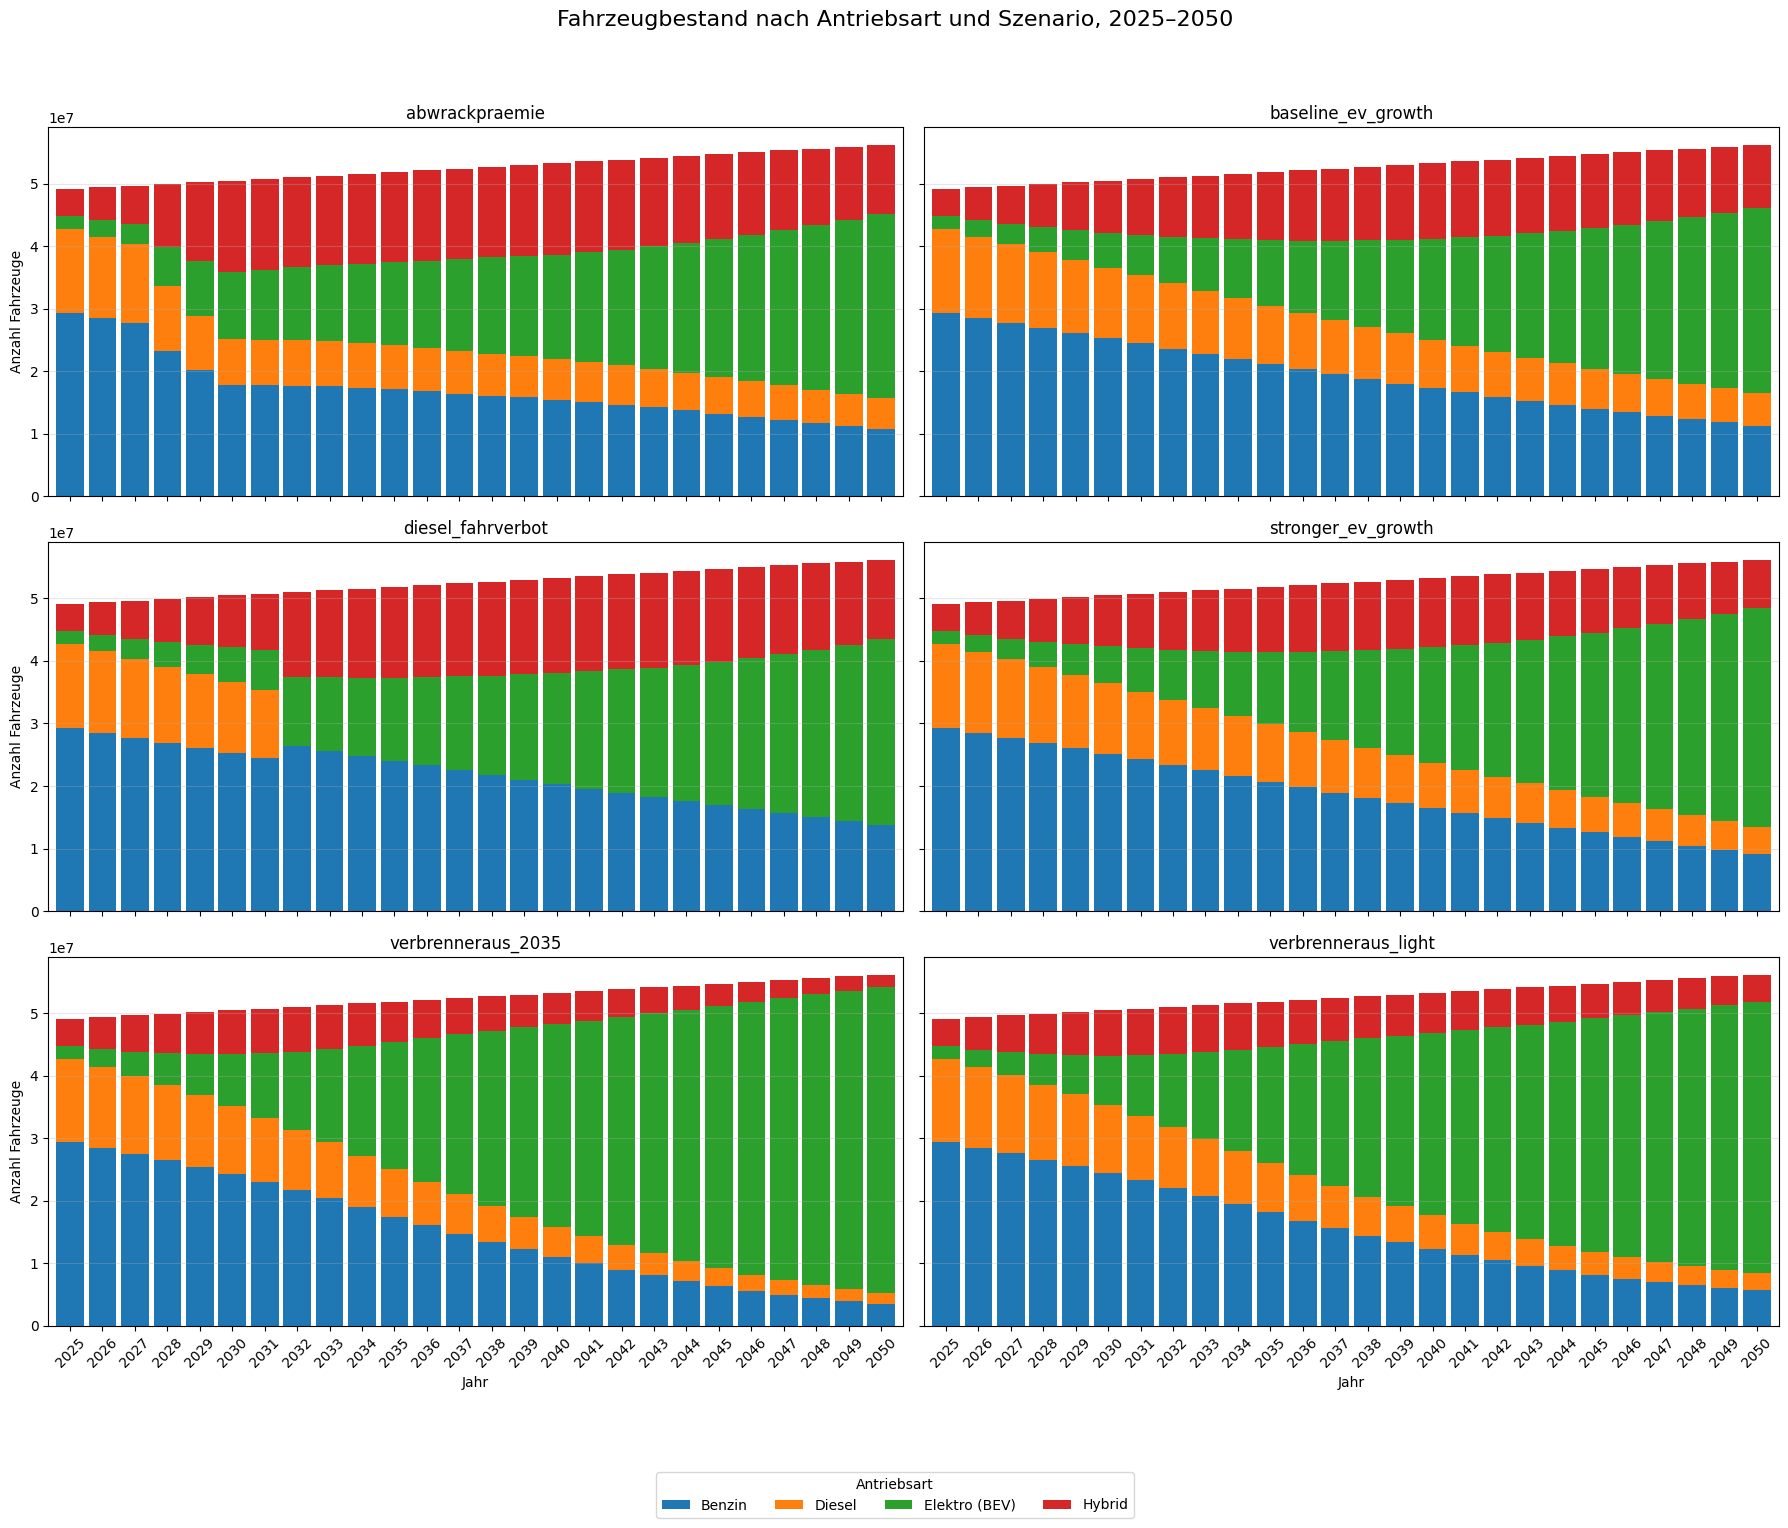

Grafik gespeichert unter:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\Results\policy_fahrzeugbestand_szenarien_antriebsarten_2025_2050.png


In [15]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Frisch berechnete Ergebnisdaten verwenden
# ------------------------------------------------------------

df = policy_final_stock_all.copy()

# ------------------------------------------------------------
# 2. Datentypen bereinigen
# ------------------------------------------------------------

df["Jahr"] = df["Jahr"].astype(int)
df["finaler_bestand"] = pd.to_numeric(df["finaler_bestand"], errors="coerce")

# ------------------------------------------------------------
# 3. Nur Jahre 2025 bis 2050 verwenden
# ------------------------------------------------------------

df = df[(df["Jahr"] >= 2025) & (df["Jahr"] <= 2050)]

# ------------------------------------------------------------
# 4. Fahrzeugbestand pro Szenario, Jahr und Antriebsart summieren
# ------------------------------------------------------------

agg = (
    df.groupby(["Szenario", "Jahr", "Antriebsart"], as_index=False)["finaler_bestand"]
    .sum()
)

# ------------------------------------------------------------
# 5. Szenarien und Antriebsarten bestimmen
# ------------------------------------------------------------

szenarien = sorted(agg["Szenario"].unique())
antriebsarten = sorted(agg["Antriebsart"].unique())

print("Gefundene Szenarien:")
print(szenarien)

print("\nGefundene Antriebsarten:")
print(antriebsarten)

# ------------------------------------------------------------
# 6. Dynamisches Plot-Raster für alle Szenarien erstellen
# ------------------------------------------------------------

ncols = 2
nrows = math.ceil(len(szenarien) / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 5 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False
)

axes = axes.flatten()

for ax, szenario in zip(axes, szenarien):
    
    data_szenario = agg[agg["Szenario"] == szenario]

    # Pivot-Tabelle:
    # Zeilen = Jahre
    # Spalten = Antriebsarten
    # Werte = Fahrzeugbestand
    pivot = (
        data_szenario
        .pivot_table(
            index="Jahr",
            columns="Antriebsart",
            values="finaler_bestand",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(range(2025, 2051), fill_value=0)
    )

    # Sicherstellen, dass in jedem Subplot alle Antriebsarten vorkommen
    pivot = pivot.reindex(columns=antriebsarten, fill_value=0)

    # Gestapeltes Balkendiagramm
    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(szenario)
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Anzahl Fahrzeuge")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

    # Einzelne Legende entfernen, da später gemeinsame Legende kommt
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Nicht benötigte Subplots ausblenden
for i in range(len(szenarien), len(axes)):
    axes[i].set_visible(False)

# ------------------------------------------------------------
# 7. Gemeinsame Legende erstellen
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Antriebsart",
    loc="lower center",
    ncol=len(antriebsarten),
    bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    "Fahrzeugbestand nach Antriebsart und Szenario, 2025–2050",
    fontsize=16
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# ------------------------------------------------------------
# 8. Grafik speichern
# ------------------------------------------------------------

output_path = results_dir / "policy_fahrzeugbestand_szenarien_antriebsarten_2025_2050.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Grafik gespeichert unter:\n{output_path}")

# Emissionen je Szenario als DataFrames

Jeder DataFrame zeigt die jährlichen Emissionen nach Lebenszyklusphase, die Jahressumme und am Ende die Summe über den gesamten Modellzeitraum. Alle Werte sind in t CO₂e angegeben.

In [16]:
# Ein DataFrame pro Szenario: Einzelteile, Jahressumme und Gesamtsumme
emissionen_phasen = results["emissions_summary_by_year_phase"].copy()
emissionen_total = results["emissions_summary_by_year_total"].copy()

phase_names = {
    "production": "Fahrzeugproduktion [t CO2e]",
    "battery_production": "Batterieproduktion [t CO2e]",
    "use": "Nutzungsphase [t CO2e]",
    "end_of_life": "End-of-Life [t CO2e]",
}
phase_columns = list(phase_names.values())

emissionen_nach_szenario = {}

for szenario in sorted(emissionen_phasen["Szenario"].unique()):
    einzelteile = (
        emissionen_phasen.loc[emissionen_phasen["Szenario"] == szenario]
        .pivot_table(
            index="emission_year",
            columns="phase",
            values="emissions_tco2e",
            aggfunc="sum",
            fill_value=0,
        )
        .rename(columns=phase_names)
        .reindex(columns=phase_columns, fill_value=0)
    )

    jahressummen = (
        emissionen_total.loc[
            emissionen_total["Szenario"] == szenario,
            ["emission_year", "total_emissions_tco2e"],
        ]
        .set_index("emission_year")
        .rename(columns={"total_emissions_tco2e": "Emissionen gesamt [t CO2e]"})
    )

    df_szenario = einzelteile.join(jahressummen, how="outer").sort_index()
    df_szenario.index.name = "Jahr"
    df_szenario.loc["Gesamt 2025–2050"] = df_szenario.sum(numeric_only=True)
    emissionen_nach_szenario[szenario] = df_szenario

# Zugriff z. B.: emissionen_nach_szenario["baseline_ev_growth"]
for szenario, df_szenario in emissionen_nach_szenario.items():
    print(f"\n{szenario}")
    display(df_szenario.style.format("{:,.0f}"))


abwrackpraemie


,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,849,102","5,342,761","131,168,233","10,638,448","170,998,544"
2026,"24,511,174","6,139,075","130,943,259","11,132,402","172,725,911"
2027,"86,501,534","23,963,563","130,458,860","10,477,304","251,401,261"
2028,"70,258,736","21,340,059","125,536,864","10,860,044","227,995,703"
2029,"62,444,181","20,642,530","120,971,652","40,962,615","245,020,977"
2030,"25,285,569","9,040,925","116,430,361","36,940,653","187,697,508"
2031,"25,362,543","9,756,146","116,045,348","34,306,630","185,470,667"
2032,"25,560,332","10,528,835","115,473,775","13,148,738","164,711,680"
2033,"24,053,739","10,567,148","114,760,327","13,298,192","162,679,406"



baseline_ev_growth


,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,849,102","5,342,761","131,168,233","10,638,448","170,998,544"
2026,"24,511,174","6,139,075","130,943,259","11,132,402","172,725,911"
2027,"25,118,043","6,958,464","130,458,860","10,477,304","173,012,672"
2028,"25,652,153","7,791,465","129,695,905","10,860,044","173,999,567"
2029,"26,412,843","8,731,445","128,632,958","11,245,248","175,022,494"
2030,"26,843,390","9,597,928","127,261,791","11,602,646","175,305,755"
2031,"27,191,367","10,459,634","125,954,684","12,016,175","175,621,861"
2032,"27,569,790","11,356,573","124,485,946","12,362,095","175,774,405"
2033,"27,975,480","12,290,025","122,902,032","12,680,993","175,848,531"



diesel_fahrverbot


...

,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,834,117","5,496,631","131,168,233","10,638,448","171,137,429"
2026,"24,483,080","6,456,889","130,894,804","11,132,402","172,967,176"
2027,"25,078,834","7,449,578","130,309,839","10,477,304","173,315,556"
2028,"25,603,965","8,464,049","129,390,844","10,861,872","174,320,731"
2029,"26,356,976","9,602,334","128,113,383","11,250,714","175,323,407"
2030,"26,782,956","10,667,030","126,463,285","11,613,531","175,526,803"
2031,"27,126,348","11,730,863","124,835,656","12,034,226","175,727,094"
2032,"27,499,473","12,838,083","122,992,924","12,389,127","175,719,607"
2033,"27,898,939","13,990,363","120,978,905","12,719,578","175,587,786"



verbrenneraus_2035


,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,714,790","6,721,912","131,168,233","10,638,448","172,243,384"
2026,"24,259,117","8,990,253","130,508,949","11,132,402","174,890,722"
2027,"24,765,514","11,372,048","129,122,334","10,477,304","175,737,200"
2028,"25,217,449","13,851,261","126,956,898","10,876,434","176,902,042"
2029,"25,906,529","16,603,046","123,960,660","11,294,269","177,764,504"
2030,"26,292,083","19,299,898","120,066,886","11,700,381","177,359,248"
2031,"26,594,363","22,042,402","115,846,913","12,178,494","176,662,173"
2032,"26,920,337","24,908,433","110,963,767","12,605,651","175,398,189"
2033,"27,265,072","27,902,588","105,436,003","13,029,428","173,633,090"



verbrenneraus_light


,Fahrzeugproduktion [t CO2e],Batterieproduktion [t CO2e],Nutzungsphase [t CO2e],End-of-Life [t CO2e],Emissionen gesamt [t CO2e]
Jahr,,,,,
2025,"23,738,819","6,475,176","131,168,233","10,638,448","172,020,677"
2026,"24,304,253","8,479,740","130,586,649","11,132,402","174,503,044"
2027,"24,828,763","10,580,508","129,361,582","10,477,304","175,248,158"
2028,"25,295,681","12,761,949","127,447,697","10,873,502","176,378,829"
2029,"25,998,034","15,183,889","124,799,083","11,285,494","177,266,501"
2030,"26,392,313","17,544,338","121,360,349","11,682,868","176,979,867"
2031,"26,703,540","19,938,819","117,668,139","12,149,367","176,459,866"
2032,"27,039,734","22,438,426","113,406,205","12,561,868","175,446,233"
2033,"27,396,253","25,047,166","108,598,827","12,966,661","174,008,908"


# Anteil der Produktion an den Gesamtemissionen

Ausgabe je Szenario und Jahr, jeweils ohne und mit Batterieproduktion. Anschließend werden der Durchschnitt über alle Szenarien sowie stärkste und schwächste Veränderungen zusammengefasst.

In [17]:
# Produktionsanteile an den jährlichen Gesamtemissionen je Szenario
emissionen_phase_wide = (
    emissionen_phasen.pivot_table(
        index=["Szenario", "emission_year"],
        columns="phase",
        values="emissions_tco2e",
        aggfunc="sum",
        fill_value=0,
    ).reset_index()
)

produktionsanteile = emissionen_phase_wide.merge(
    emissionen_total[["Szenario", "emission_year", "total_emissions_tco2e"]],
    on=["Szenario", "emission_year"],
    how="left",
)
produktionsanteile["Produktion ohne Batterie [%]"] = (
    100 * produktionsanteile["production"] / produktionsanteile["total_emissions_tco2e"]
)
produktionsanteile["Produktion inklusive Batterie [%]"] = (
    100 * (produktionsanteile["production"] + produktionsanteile["battery_production"])
    / produktionsanteile["total_emissions_tco2e"]
)

anteil_spalten = [
    "Produktion ohne Batterie [%]",
    "Produktion inklusive Batterie [%]",
]
produktionsanteile_nach_szenario = {
    szenario: gruppe.set_index("emission_year")[anteil_spalten]
        .rename_axis("Jahr").sort_index()
    for szenario, gruppe in produktionsanteile.groupby("Szenario")
}

for szenario, df_anteile in produktionsanteile_nach_szenario.items():
    print(f"\n{szenario}")
    display(df_anteile.style.format("{:.2f} %"))


abwrackpraemie


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,13.95 %,17.07 %
2026,14.19 %,17.75 %
2027,34.41 %,43.94 %
2028,30.82 %,40.18 %
2029,25.49 %,33.91 %
2030,13.47 %,18.29 %
2031,13.67 %,18.93 %
2032,15.52 %,21.91 %
2033,14.79 %,21.28 %



baseline_ev_growth


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,13.95 %,17.07 %
2026,14.19 %,17.75 %
2027,14.52 %,18.54 %
2028,14.74 %,19.22 %
2029,15.09 %,20.08 %
2030,15.31 %,20.79 %
2031,15.48 %,21.44 %
2032,15.68 %,22.15 %
2033,15.91 %,22.90 %



diesel_fahrverbot


...

,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,13.93 %,17.14 %
2026,14.15 %,17.89 %
2027,14.47 %,18.77 %
2028,14.69 %,19.54 %
2029,15.03 %,20.51 %
2030,15.26 %,21.34 %
2031,15.44 %,22.11 %
2032,15.65 %,22.96 %
2033,15.89 %,23.86 %



verbrenneraus_2035


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,13.77 %,17.67 %
2026,13.87 %,19.01 %
2027,14.09 %,20.56 %
2028,14.26 %,22.08 %
2029,14.57 %,23.91 %
2030,14.82 %,25.71 %
2031,15.05 %,27.53 %
2032,15.35 %,29.55 %
2033,15.70 %,31.77 %



verbrenneraus_light


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,13.80 %,17.56 %
2026,13.93 %,18.79 %
2027,14.17 %,20.21 %
2028,14.34 %,21.58 %
2029,14.67 %,23.23 %
2030,14.91 %,24.83 %
2031,15.13 %,26.43 %
2032,15.41 %,28.20 %
2033,15.74 %,30.14 %


In [18]:
# Kompakte Kennzahlen für den Ergebnisteil
erstes_jahr = int(produktionsanteile["emission_year"].min())
letztes_jahr = int(produktionsanteile["emission_year"].max())

anteile_start_ende = produktionsanteile.loc[
    produktionsanteile["emission_year"].isin([erstes_jahr, letztes_jahr]),
    ["Szenario", "emission_year", *anteil_spalten],
].pivot(index="Szenario", columns="emission_year", values=anteil_spalten)
anteile_start_ende.columns = [
    f"{kennzahl} ({jahr})" for kennzahl, jahr in anteile_start_ende.columns
]

for kennzahl in anteil_spalten:
    anteile_start_ende[f"Veränderung {kennzahl} [Prozentpunkte]"] = (
        anteile_start_ende[f"{kennzahl} ({letztes_jahr})"]
        - anteile_start_ende[f"{kennzahl} ({erstes_jahr})"]
    )

durchschnitt_nach_jahr = produktionsanteile.groupby("emission_year")[anteil_spalten].mean()
durchschnitt_nach_jahr.index.name = "Jahr"

display(anteile_start_ende.style.format("{:.2f}"))
display(durchschnitt_nach_jahr.style.format("{:.2f} %"))

for kennzahl in anteil_spalten:
    start_mittel = durchschnitt_nach_jahr.loc[erstes_jahr, kennzahl]
    ende_mittel = durchschnitt_nach_jahr.loc[letztes_jahr, kennzahl]
    delta_spalte = f"Veränderung {kennzahl} [Prozentpunkte]"
    staerkstes_szenario = anteile_start_ende[delta_spalte].idxmax()
    schwaechstes_szenario = anteile_start_ende[delta_spalte].idxmin()
    print(f"\n{kennzahl}")
    print(
        f"Durchschnitt: {start_mittel:.2f} % ({erstes_jahr}) -> "
        f"{ende_mittel:.2f} % ({letztes_jahr}); "
        f"Änderung {ende_mittel - start_mittel:+.2f} Prozentpunkte."
    )
    print(
        f"Stärkster Anstieg: {staerkstes_szenario} "
        f"({anteile_start_ende.loc[staerkstes_szenario, delta_spalte]:+.2f} Prozentpunkte)."
    )
    print(
        f"Schwächste Veränderung: {schwaechstes_szenario} "
        f"({anteile_start_ende.loc[schwaechstes_szenario, delta_spalte]:+.2f} Prozentpunkte)."
    )

,Produktion ohne Batterie [%] (2025),Produktion ohne Batterie [%] (2050),Produktion inklusive Batterie [%] (2025),Produktion inklusive Batterie [%] (2050),Veränderung Produktion ohne Batterie [%] [Prozentpunkte],Veränderung Produktion inklusive Batterie [%] [Prozentpunkte]
Szenario,,,,,,
abwrackpraemie,13.95,18.99,17.07,36.04,5.04,18.96
baseline_ev_growth,13.95,18.91,17.07,35.88,4.96,18.81
diesel_fahrverbot,13.95,18.53,17.07,35.22,4.59,18.15
stronger_ev_growth,13.93,20.27,17.14,42.31,6.34,25.17
verbrenneraus_2035,13.77,27.41,17.67,58.21,13.65,40.54
verbrenneraus_light,13.80,24.72,17.56,49.45,10.92,31.88


,Produktion ohne Batterie [%],Produktion inklusive Batterie [%]
Jahr,,
2025,13.89 %,17.26 %
2026,14.09 %,18.15 %
2027,17.70 %,23.43 %
2028,17.26 %,23.64 %
2029,16.66 %,23.62 %
2030,14.85 %,21.96 %
2031,18.37 %,27.61 %
2032,15.66 %,24.65 %
2033,15.53 %,25.30 %



Produktion ohne Batterie [%]
Durchschnitt: 13.89 % (2025) -> 21.47 % (2050); Änderung +7.58 Prozentpunkte.
Stärkster Anstieg: verbrenneraus_2035 (+13.65 Prozentpunkte).
Schwächste Veränderung: diesel_fahrverbot (+4.59 Prozentpunkte).

Produktion inklusive Batterie [%]
Durchschnitt: 17.26 % (2025) -> 42.85 % (2050); Änderung +25.59 Prozentpunkte.
Stärkster Anstieg: verbrenneraus_2035 (+40.54 Prozentpunkte).
Schwächste Veränderung: diesel_fahrverbot (+18.15 Prozentpunkte).
